
# Lab 9: Quantun Computing - Rabi Oscillations

Nombre estudiante:

c.c:

## Exercise 1: $NH_3$ molecule

An example of the quantum oscillations in two-level systems may be rather unexpected; for example, the ammonium molecule 

![NH3](NH3.png)

 It has two symmetric states that differ by the inversion of the nitrogen atom relative to the plane of the three hydrogen atoms, which are weakly coupled due to quantum-mechanical tunneling of the nitrogen atom through the plane of the hydrogen atoms. Since for this particular molecule, in the absence of external fields, the level splitting $\Delta E$ corresponds to an experimentally convenient frequency $\Omega/2\pi\approx$ 24.79 GHz.

 1. Supose a detuning frequency $\Omega_R/2$.
 2. Compute the Rabi frequency for NH3 molecule in Hz and do a plot of the Rabi oscillation. Supose that the initial state is $\ket{2}$.
 
 [see](https://phys.libretexts.org/Bookshelves/Quantum_Mechanics/Essential_Graduate_Physics_-_Quantum_Mechanics_(Likharev)/05%3A_Some_Exactly_Solvable_Problems/5.01%3A_Two-level_Systems)

### Solución problema de Rabi:

Para el sistema de dos niveles del $NH_3$ se propone un splitting energetico $\Delta E$ dado por una frecuencia de conversión $f = \Omega_0/2\pi \approx 24.79$ GHZ, es decir $\Delta E = h f $. El Hamiltoniano del sistema viene representado por la siguiente matriz:

$$H = \begin{pmatrix}
    E_0 & -A \\
    -A & E_0
\end{pmatrix} $$

Los autovalores de esta matriz corresponden a los terminos $E_{\pm} = E_0 \pm A$ de modo que $\Delta E = 2A$ y por lo tanto $A = h f /2$.

La frecuencia ángular de Rabi viene dado por 

$$ \Omega_R = \frac{|H_{12}|}{\hbar} = \frac{A}{\hbar} = \frac{h f}{2 \hbar} =  \pi f$$

Al reemplazar los valores númericos se determina que $f_R = \Omega_R / 2\pi = f/2 = 12.395$ GHz.

Considerando un detuning $\Delta = \Omega_R/2$, se establece que $\Omega = \sqrt{ \Omega_R^2 + \Delta^2 } = \sqrt{5} \Omega_R / 2$, por lo que la frecuencia $f_\Omega = \Omega/2\pi \approx 13.858$ GHz

Dado el estado inicial $\ket{2}$, se determina las probabilidades $P_i(t)$ de medir cada estado como:

\begin{align*}
    P_1(t) &= \frac{\Omega_R^2}{\Omega^2} \sin^2{(\Omega t)} \\
    P_2(t) &= \cos^2{(\Omega t)} + \frac{\Delta^2}{\Omega^2} \sin^2{(\Omega t)} 
\end{align*}

Reemplazando las amplitudes se determinan como $\frac{\Omega_R^2}{\Omega^2} = \frac{4}{5} = 0.8$ y $\frac{\Delta^2}{\Omega^2} = \frac{1}{5} = 0.2$


Frecuencia de Rabi lineal (f_R): 12.395 GHz
Frecuencia efectiva lineal (f_eff): 13.858 GHz
Período de oscilación observable (T): 36.08 ps


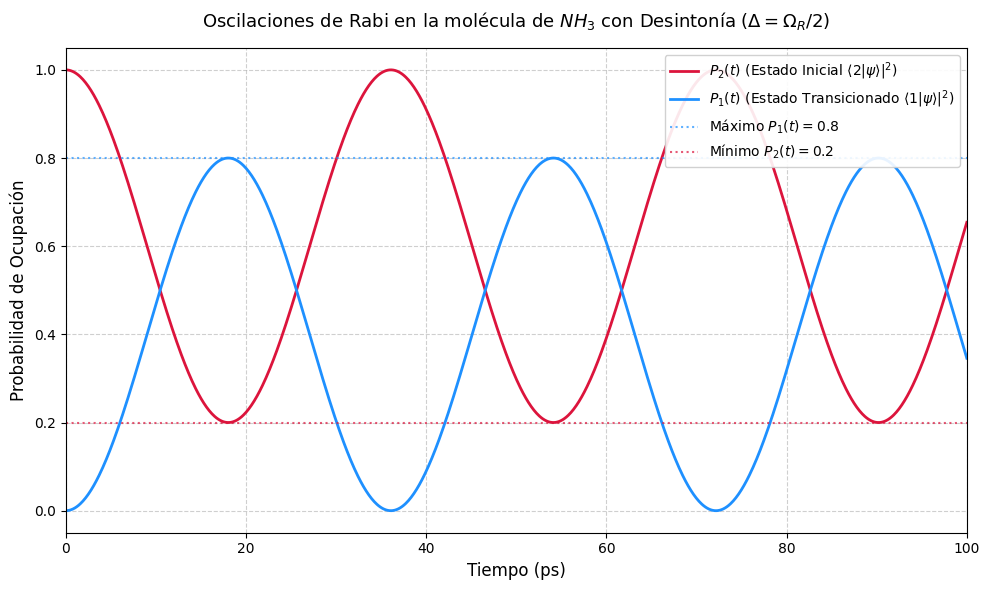

In [42]:
import numpy as np
import matplotlib.pyplot as plt

f0 = 24.79e9          
omega_R = np.pi * f0  
f_R = f0 / 2         

detuning = omega_R / 2               
omega_eff = np.sqrt(omega_R**2 + detuning**2) 

print(f"Frecuencia de Rabi lineal (f_R): {f_R / 1e9:.3f} GHz")
print(f"Frecuencia efectiva lineal (f_eff): {omega_eff / (2 * np.pi) * 1e-9:.3f} GHz")
print(f"Período de oscilación observable (T): {1e12 / (2 * omega_eff / (2 * np.pi)):.2f} ps")

t = np.linspace(0, 100e-12, 1000)

P1 = (omega_R**2 / omega_eff**2) * (np.sin(omega_eff * t))**2
P2 = (np.cos(omega_eff * t))**2 + (detuning**2 / omega_eff**2) * (np.sin(omega_eff * t))**2

plt.figure(figsize=(10, 6))
plt.plot(t * 1e12, P2, label=r'$P_2(t)$ (Estado Inicial $\langle 2 \vert \psi \rangle|^2$)', color='crimson', lw=2)
plt.plot(t * 1e12, P1, label=r'$P_1(t)$ (Estado Transicionado $\langle 1 \vert \psi \rangle|^2$)', color='dodgerblue', lw=2)

plt.title(r'Oscilaciones de Rabi en la molécula de $NH_3$ con Desintonía ($\Delta = \Omega_R/2$)', fontsize=13, pad=15)
plt.xlabel('Tiempo (ps)', fontsize=12)
plt.ylabel('Probabilidad de Ocupación', fontsize=12)
plt.xlim(0, 100)
plt.ylim(-0.05, 1.05)
plt.grid(True, linestyle='--', alpha=0.6)
plt.axhline(0.8, color='dodgerblue', linestyle=':', alpha=0.7, label='Máximo $P_1(t) = 0.8$')
plt.axhline(0.2, color='crimson', linestyle=':', alpha=0.7, label='Mínimo $P_2(t) = 0.2$')
plt.legend(loc='upper right', fontsize=10, framealpha=0.9)

# Mostrar gráfica
plt.tight_layout()
plt.show()

## Exercise: Bell state

1. Creates a quantum circuit for two qubits, consisting of the quantum gates needed to create a `Bell state`  (two entangled qubits). The quantum circuit then terminates with quantum measurements, extracting one bit from each qubit.

2. Add a third qubit by changing to QuantumCircuit(3), and add a second CX gate with qc.cx(1,2). The measurements should then change to 000 and 111, which means all three of these qubits have been entangled.

3. See your results shift by adding qc.x(1) to the end of the circuit.

### Solución ejercicio estados de Bell

In [43]:
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
simulator = AerSimulator()

In [44]:
#1. Crear un circuito con 2 qubits entrelazados 

qc1 = QuantumCircuit(2,2)

qc1.barrier()
qc1.h(0)          
qc1.cx(0, 1)      
qc1.barrier()
qc1.measure([0,1],[0,1])

counts1 = simulator.run(qc1).result().get_counts()
print("Resultados (Estado de Bell):", counts1)

qc1.draw()

Resultados (Estado de Bell): {'11': 529, '00': 495}


░ ┌───┐      ░ ┌─┐   
q_0: ─░─┤ H ├──■───░─┤M├───
      ░ └───┘┌─┴─┐ ░ └╥┘┌─┐
q_1: ─░──────┤ X ├─░──╫─┤M├
      ░      └───┘ ░  ║ └╥┘
c: 2/═════════════════╩══╩═
                      0  1

In [45]:
#2. Crear un circuito con 3 qubits entrelazados

qc2 = QuantumCircuit(3)

qc2.barrier()
qc2.h(0)
qc2.cx(0, 1)
qc2.cx(1, 2)
qc2.measure_all()
counts2 = simulator.run(qc2).result().get_counts()

print("Resultados (3 qubits entrelazados):", counts2)

qc2.draw()

Resultados (3 qubits entrelazados): {'111': 485, '000': 539}


░ ┌───┐           ░ ┌─┐      
   q_0: ─░─┤ H ├──■────────░─┤M├──────
         ░ └───┘┌─┴─┐      ░ └╥┘┌─┐   
   q_1: ─░──────┤ X ├──■───░──╫─┤M├───
         ░      └───┘┌─┴─┐ ░  ║ └╥┘┌─┐
   q_2: ─░───────────┤ X ├─░──╫──╫─┤M├
         ░           └───┘ ░  ║  ║ └╥┘
meas: 3/══════════════════════╩══╩══╩═
                              0  1  2

In [46]:
# Crear circuito con la compuerta de desplazamiento
qc3 = QuantumCircuit(3)

qc3.barrier()
qc3.h(0)
qc3.cx(0, 1)
qc3.cx(1, 2)
qc3.x(1)
qc3.measure_all()

counts3 = simulator.run(qc3).result().get_counts()

print("Resultados con desplazamiento X(1):", counts3)
qc3.draw()

Resultados con desplazamiento X(1): {'101': 503, '010': 521}


░ ┌───┐                ░ ┌─┐      
   q_0: ─░─┤ H ├──■─────────────░─┤M├──────
         ░ └───┘┌─┴─┐     ┌───┐ ░ └╥┘┌─┐   
   q_1: ─░──────┤ X ├──■──┤ X ├─░──╫─┤M├───
         ░      └───┘┌─┴─┐└───┘ ░  ║ └╥┘┌─┐
   q_2: ─░───────────┤ X ├──────░──╫──╫─┤M├
         ░           └───┘      ░  ║  ║ └╥┘
meas: 3/═══════════════════════════╩══╩══╩═
                                   0  1  2

Nota: 5.0... muy bien por acercarse a estos temas. 